In [1]:
import numpy as np
from matplotlib import pyplot as plt

from pyloki.config import ParamLimits, PulsarSearchConfig
from pyloki.detection import thresholding
from pyloki.ffa import DynamicProgramming
from pyloki.periodogram import PruningStatsPlotter, ScatteredPeriodogram
from pyloki.prune import prune_dyp_tree
from pyloki.simulation.pulse import PulseSignalConfig

tobs = 2147.483648


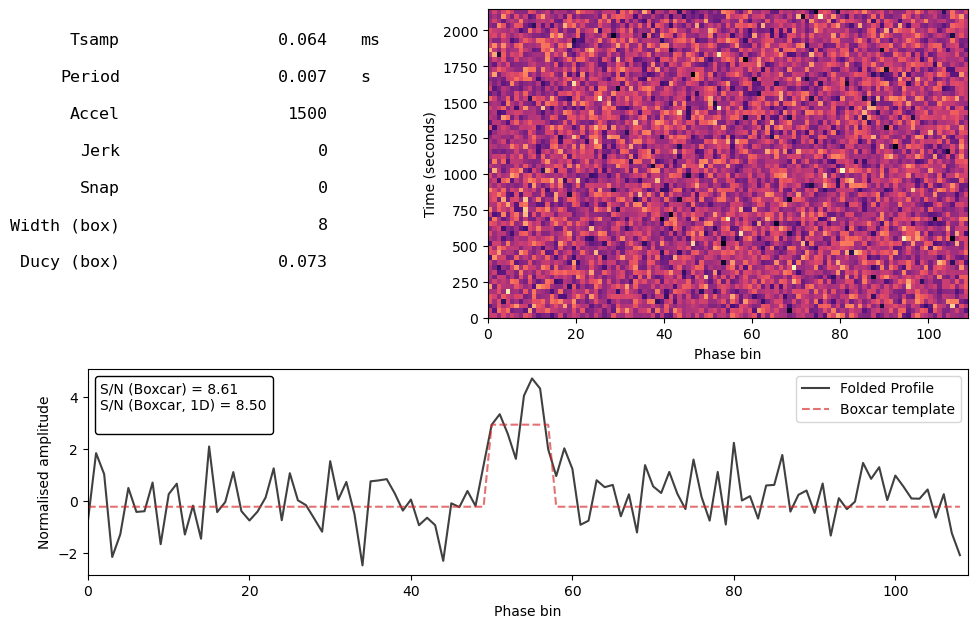

In [2]:
pulsar_period = 0.007
dt = 64e-6
accel = 1500
nsamps = 2**25
mod_kwargs = {"acc": accel}
cfg = PulseSignalConfig(
    period=pulsar_period,
    dt=dt,
    nsamps=nsamps,
    snr=8.5,
    ducy=0.1,
    mod_kwargs=mod_kwargs,
)
print(f"tobs = {cfg.tobs}")
tim_data = cfg.generate(shape="gaussian")
tim_data.plot_fold(cfg.freq, cfg.fold_bins, mod_kwargs=mod_kwargs)
plt.show()

In [3]:
eta = 1
nbins = 64
p = ParamLimits.from_upper((140.0, 150.0), [accel], (-2500.0, 2500.0), cfg.tobs)
print(f"Param limits: {p.limits}")
bseg_brute = cfg.nsamps // 16384
bseg_ffa = cfg.nsamps // 128
search_cfg = PulsarSearchConfig(
    nsamps=cfg.nsamps,
    tsamp=cfg.dt,
    nbins=nbins,
    eta=eta,
    param_limits=p.limits,
    bseg_brute=bseg_brute,
    bseg_ffa=bseg_ffa,
    prune_poly_order=2,
    ducy_max=0.5,
    wtsp=1.2,
    use_fourier=True,
    branch_max=32
)
dyp = DynamicProgramming(tim_data, search_cfg)
dyp.initialize()
dyp.execute()

Param limits: [[-2500.          2500.        ]
 [  138.74643398   151.34310645]]


Task was destroyed but it is pending!
task: <Task pending name='Task-37' coro=<_async_in_context.<locals>.run_in_context() done, defined at /opt/homebrew/Caskroom/miniforge/base/envs/py3/lib/python3.14/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-38' coro=<Kernel.shell_main() running at /opt/homebrew/Caskroom/miniforge/base/envs/py3/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/homebrew/Caskroom/miniforge/base/envs/py3/lib/python3.14/site-packages/zmq/eventloop/zmqstream.py:563]>
Task was destroyed but it is pending!
task: <Task pending name='Task-38' coro=<Kernel.shell_main() running at /opt/homebrew/Caskroom/miniforge/base/envs/py3/lib/python3.14/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>
/opt/homebrew/Caskroom/miniforge/base/envs/py3/lib/python3.14/site-packages/numba/core/compiler_machinery.py:399: RuntimeWarning: coroutine 'Kernel.shell_

2026-04-25 12:14:58 INFO     - pyloki.ffa - FFA initialize: Grid sizes: [2.88255907e+07 2.38418579e-01]

2026-04-25 12:15:01 INFO     - pyloki.ffa - ffa level:  0, leaves: 5.73, fold dims: (16384, 1, 53, 2, 33)

                    INFO     - pyloki.ffa - ffa_initialize finished, Elapsed time: 3.813 seconds

...

                    INFO     - pyloki.ffa - ffa level:  5, leaves: 10.72, fold dims: (512, 1, 1691, 2, 33)

                    INFO     - pyloki.ffa - ffa level:  6, leaves: 11.72, fold dims: (256, 1, 3382, 2, 33)

2026-04-25 12:15:07 INFO     - pyloki.ffa - ffa level:  7, leaves: 14.31, fold dims: (128, 3, 6763, 2, 33)

                    INFO     - pyloki.ffa - FFA complete: Grid sizes: [1.75937443e+03 1.86264515e-03]

                    INFO     - pyloki.ffa - ffa_execute finished, Elapsed time: 5.565 seconds

In [4]:
branching_pattern = search_cfg.generate_branching_pattern(kind="poly_taylor_moving", ref_seg=0)
branching_pattern

array([4.        , 7.44566021, 1.31313673, 1.        , 2.36409419,
       3.80695492, 1.        , 2.36409419, 1.        , 1.26898497,
       1.        , 1.        , 1.        , 1.        , 2.36409419,
       1.        , 1.        , 3.80695492, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       2.36409419, 1.        , 1.        , 1.        , 1.        ,
       1.26898497, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.66748333,
       1.41776182, 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 3.80695492, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

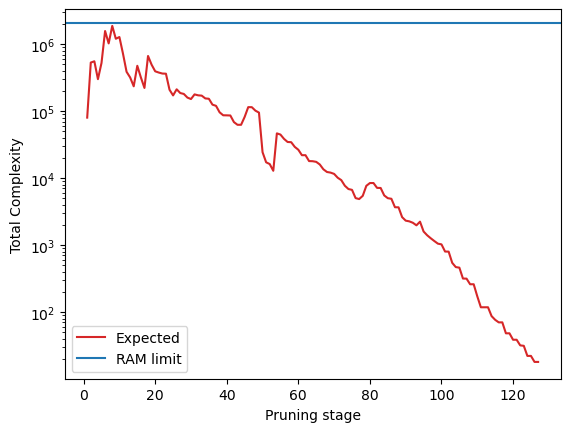

In [5]:
thresholds = np.array([1.9, 2.2, 2.4, 2.8, 2.8, 2.8, 3. , 3. , 3.2, 3.1, 3.4, 3.6, 3.5,
       3.6, 3.5, 3.7, 3.8, 3.8, 3.9, 3.9, 3.7, 3.6, 3.3, 4. , 4. , 4.3,
       4.2, 4. , 4.1, 4. , 4. , 3.9, 3.7, 3.9, 3.7, 4. , 3.9, 4.1, 4.1,
       3.8, 3.7, 4.1, 4.1, 3.7, 4.2, 4. , 3.8, 4.1, 4.1, 4.8, 4.9, 4.8,
       4.9, 4.8, 4.7, 4.8, 4.8, 4.6, 4.8, 4.8, 4.9, 4.6, 4.9, 4.7, 4.7,
       4.8, 4.9, 4.9, 4.8, 4.8, 4.9, 4.9, 5. , 5. , 4.9, 5.1, 5. , 5.1,
       4.9, 5.1, 4.5, 5.1, 4.9, 5.2, 5.2, 5.1, 5.3, 5.1, 5.4, 5.4, 5.3,
       5.3, 5.4, 5.2, 5.5, 5.5, 5.5, 5.5, 5.5, 5.4, 5.6, 5.4, 5.7, 5.7,
       5.6, 5.8, 5.6, 5.8, 5.4, 5.9, 6. , 5.3, 5.3, 6. , 6. , 6. , 5.4,
       6.1, 5.5, 6.1, 5.5, 6.1, 6. , 6.2, 5.5, 6.2, 5.5])
thresh_state = thresholding.evaluate_scheme(
    thresholds,
    branching_pattern,
    ref_ducy=0.1,
    nbins=64,
    ntrials=1024,
    snr_final=8.5,
    ducy_max=0.5,
    wtsp=1.2,
)
x = np.arange(1, len(branching_pattern) + 1)
plt.semilogy(
    x,
    np.array(thresh_state.get_info("complexity")) * dyp.nparam_vol,
    label="Expected",
    c="tab:red",
)
plt.axhline(2**21, label="RAM limit", c="tab:blue")
plt.xlabel("Pruning stage")
plt.ylabel("Total Complexity")
plt.legend()
plt.show()

In [7]:
result_file = prune_dyp_tree(
    dyp,
    thresholds,
    n_runs=32,
    max_sugg=2**21,
    outdir="pruning_results/accel_test/",
    file_prefix="test_accel",
    poly_basis="taylor",
    n_workers=4,
    use_moving_grid=True,
)

2026-04-25 11:00:37 INFO     - pyloki.prune - Starting Pruning for 32 runs, with 4 workers

Output()

2026-04-25 11:05:30 INFO     - pyloki.prune - Pruning complete. Results saved to                                   
                             pruning_results/accel_test/test_accel_pruning_nstages_128_results.h5

In [8]:
pgram = ScatteredPeriodogram.load(result_file)
print(f"True params, a: {cfg.mod_kwargs["acc"]:.3f}, f: {cfg.freq:.10f}")
print(pgram.get_summary_cands(10, score_type="score", run_id=None))

True params, a: 1500.000, f: 142.8571428571
Top candidates:
dparams: daccel: 0.1906263096, dfreq: 2.299489501e-05
Run: 058_15, S/N (EP): 8.75, S/N: 8.43, accel: 1499.99, freq: 142.857145
Run: 093_24, S/N (EP): 7.97, S/N: 8.19, accel: 1499.96, freq: 142.857149
Run: 101_26, S/N (EP): 8.04, S/N: 8.15, accel: 1500.08, freq: 142.857145
Run: 097_25, S/N (EP): 7.58, S/N: 8.03, accel: 1500.02, freq: 142.857157
Run: 097_25, S/N (EP): 7.68, S/N: 7.86, accel: 1500.02, freq: 142.857134
Run: 101_26, S/N (EP): 8.31, S/N: 7.75, accel: 1500.08, freq: 142.857122
Run: 093_24, S/N (EP): 8.25, S/N: 7.67, accel: 1499.96, freq: 142.857126
Run: 058_15, S/N (EP): 7.61, S/N: 7.55, accel: 1499.99, freq: 142.857122
Run: 101_26, S/N (EP): 7.41, S/N: 7.54, accel: 1499.89, freq: 142.857131
Run: 073_19, S/N (EP): 7.27, S/N: 7.53, accel: -1140.86, freq: 149.886227


In [9]:
print(pgram.get_best_in_each_run())

Best candidate in each run:
dparams: daccel: 0.1906263096, dfreq: 2.299489501e-05
Run: 002_01, S/N (EP): 6.50, S/N: 6.78, accel: 1850.32, freq: 150.336583
Run: 006_02, S/N (EP): 6.66, S/N: 6.59, accel: 160.60, freq: 143.144940
Run: 010_03, S/N (EP): 6.88, S/N: 7.01, accel: 927.99, freq: 140.909840
Run: 014_04, S/N (EP): 6.48, S/N: 6.55, accel: -2474.62, freq: 151.866305
Run: 018_05, S/N (EP): 6.57, S/N: 6.70, accel: 1490.45, freq: 144.440790
Run: 022_06, S/N (EP): 6.86, S/N: 7.08, accel: -116.09, freq: 142.978134
Run: 026_07, S/N (EP): 6.57, S/N: 7.03, accel: -116.09, freq: 142.978143
Run: 030_08, S/N (EP): 6.24, S/N: 6.71, accel: 80.13, freq: 144.581435
Run: 034_09, S/N (EP): 6.60, S/N: 7.01, accel: -116.10, freq: 142.978129
Run: 038_10, S/N (EP): 6.68, S/N: 6.55, accel: -566.43, freq: 150.840363
Run: 042_11, S/N (EP): 6.92, S/N: 6.74, accel: 1558.34, freq: 140.393764
Run: 046_12, S/N (EP): 6.45, S/N: 5.66, accel: -410.00, freq: 141.903437
Run: 050_13, S/N (EP): 6.43, S/N: 6.59, accel

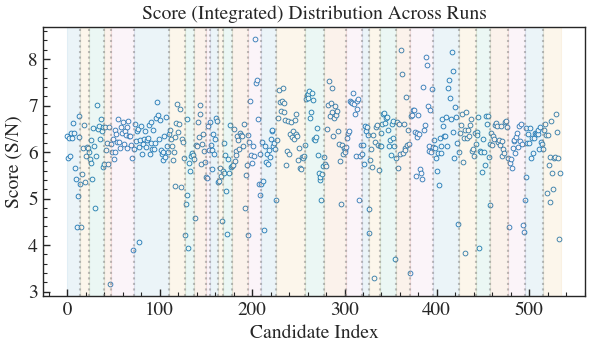

In [10]:
pgram.plot_scores(kind="scatter", score_type="score", run_id=None)
plt.show()

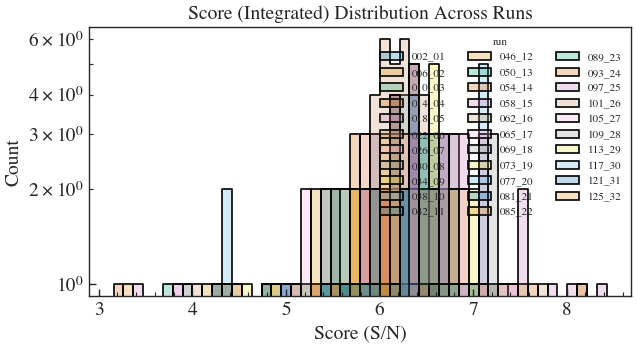

In [11]:
pgram.plot_scores(kind="hist", run_id=None)
plt.show()

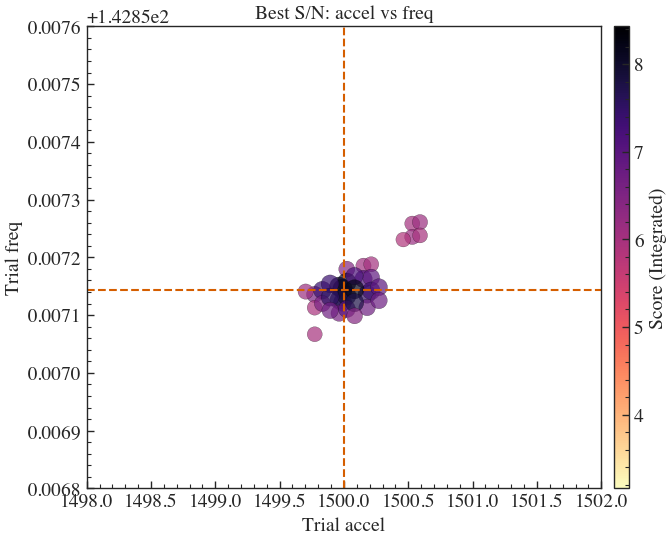

In [12]:
pgram.plot_correlation("accel", "freq", true_values={"accel": cfg.mod_kwargs["acc"], "freq": cfg.freq}, x_lim=(1498, 1502), y_lim=(142.8568, 142.8576), run_id=None)
plt.show()

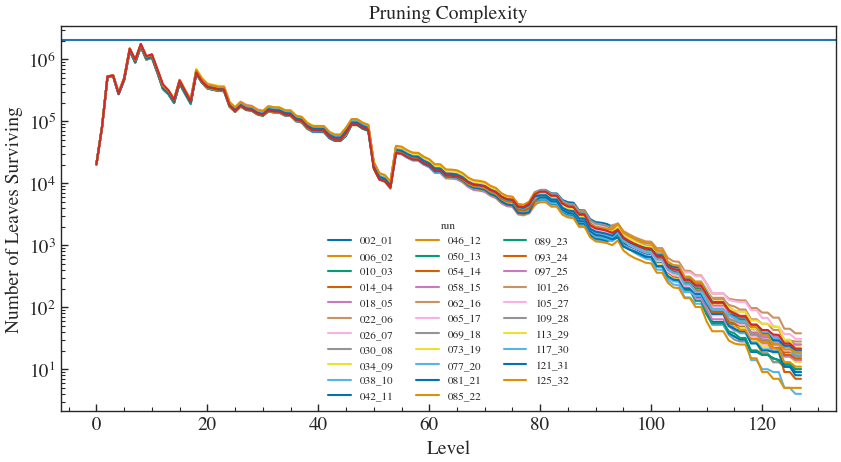

In [13]:
pstats = PruningStatsPlotter.load(result_file)
fig = pstats.plot_level_stats(run_id=None)
x = np.arange(0, len(branching_pattern) + 1)
ax_list = fig.axes
ax_list[0].plot(x, np.concatenate(([1], thresh_state.get_info("complexity"))) * dyp.nparam_vol, label="Expected", c="tab:red")
ax_list[0].axhline(2**21, label="RAM limit", c="tab:blue")
plt.show()